# <span style='color:#009999'> <span style='font-family:serif'> <font size="15"> **DYAMOND data access demonstration using `xarray`**
 
    
    
<font size="3"> This notebook demonstrates easy access to DYAMOND in `zarr` format, available on Johns Hopkins University's SciServer/Grendel domain.

<!--
<font size="3"> For quick access to surface (2D) variables, and to 3D variables subsampled in the vertical direction, see the [`LLC4320_2D_subsampled_access_demonstration.ipynb`]() notebook.


<span style='color:#0066cc'><font size="5"> **The current grendel environment requires**:
```python
pip install --upgrade fsspec
pip install --upgrade xarray
pip install --upgrade dask
pip install --upgrade distributed
-->
    
<font size="3"> Miguel A. Jimenez-Urias December '25


In [1]:
import xarray as xr
print("xarray: ", xr.__version__)
import matplotlib.pyplot as plt

xarray:  2022.11.0


<span style='color:#0066cc'><font size="5"> **DYAMOND grid and masks**

In [2]:
%%time
path = '/home/idies/workspace/poseidon_ceph/DYAMOND/*'
ds = xr.open_mfdataset(path, engine='zarr', parallel=True)
ds = ds.set_coords([var for var in ds.data_vars if "time" not in ds[var].dims])
ds

CPU times: user 4.29 s, sys: 1.22 s, total: 5.5 s
Wall time: 4.77 s


<xarray.Dataset>
Dimensions:      (face: 13, j: 2160, i: 2160, i_g: 2160, j_g: 2160, k: 90,
                  k_l: 90, k_p1: 91, k_u: 90, time: 10366, time_fx: 10366)
Coordinates: (12/56)
    CS           (face, j, i) float32 dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
  * face         (face) int64 0 1 2 3 4 5 6 7 8 9 10 11 12
  * i            (i) int64 0 1 2 3 4 5 6 ... 2153 2154 2155 2156 2157 2158 2159
  * i_g          (i_g) int64 0 1 2 3 4 5 6 ... 2154 2155 2156 2157 2158 2159
  * j            (j) int64 0 1 2 3 4 5 6 ... 2153 2154 2155 2156 2157 2158 2159
  * j_g          (j_g) int64 0 1 2 3 4 5 6 ... 2154 2155 2156 2157 2158 2159
    ...           ...
    rLowS        (face, j_g, i) float32 dask.array<chunksize=(1, 2160, 720), meta=np.ndarray>
    rLowW        (face, j, i_g) float32 dask.array<chunksize=(1, 720, 2160), meta=np.ndarray>
    rSurfC       (face, j, i) float32 dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    rSurfS       (face, j_g, i) float32 dask.array<chunksize=(1, 2160, 720), meta=np.ndarray>
    rSurfW       (face, j, i_g) float32 dask.array<chunksize=(1, 720, 2160), meta=np.ndarray>
    rhoRef       (k) float32 dask.array<chunksize=(90,), meta=np.ndarray>
Data variables: (12/21)
    Eta          (time, face, j, i) float32 dask.array<chunksize=(1, 1, 720, 720), meta=np.ndarray>
    KPPhbl       (time, face, j, i) float32 dask.array<chunksize=(1, 1, 720, 720), meta=np.ndarray>
    PS           (time, face, j, i) float32 dask.array<chunksize=(1, 1, 720, 720), meta=np.ndarray>
    PhiBot       (time, face, j, i) float32 dask.array<chunksize=(1, 1, 720, 720), meta=np.ndarray>
    SIarea       (time, face, j, i) float32 dask.array<chunksize=(1, 1, 720, 720), meta=np.ndarray>
    SIheff       (time, face, j, i) float32 dask.array<chunksize=(1, 1, 720, 720), meta=np.ndarray>
    ...           ...
    Theta        (time, k, face, j, i) float32 dask.array<chunksize=(1, 90, 1, 720, 720), meta=np.ndarray>
    U            (time, k, face, j, i_g) float32 dask.array<chunksize=(1, 90, 1, 720, 720), meta=np.ndarray>
    U10M         (time, face, j, i) float32 dask.array<chunksize=(1, 1, 720, 720), meta=np.ndarray>
    V            (time, k, face, j_g, i) float32 dask.array<chunksize=(1, 90, 1, 720, 720), meta=np.ndarray>
    V10M         (time, face, j, i) float32 dask.array<chunksize=(1, 1, 720, 720), meta=np.ndarray>
    W            (time, k_l, face, j, i) float32 dask.array<chunksize=(1, 90, 1, 720, 720), meta=np.ndarray>

In [3]:
print("Size of dataset (uncompressed) : ", ds.nbytes/1e15, "Petabytes")

Size of dataset (uncompressed) :  1.18710848979002 Petabytes


<span style='color:#0066cc'><font size="5">**Some plotting examples**

<font size="3">The following approach of closing the client before plotting is much faster.

CPU times: user 1.64 s, sys: 177 ms, total: 1.82 s
Wall time: 1.95 s


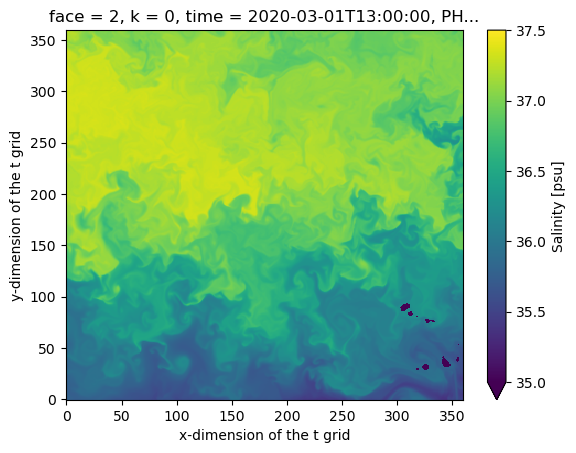

In [4]:
%%time
ds['Salt'].isel(time=1000, k=0, face=2, i=slice(0, 360), j=slice(0, 360)).plot(vmin=35, vmax=37.5);

CPU times: user 1.51 s, sys: 154 ms, total: 1.66 s
Wall time: 1.68 s


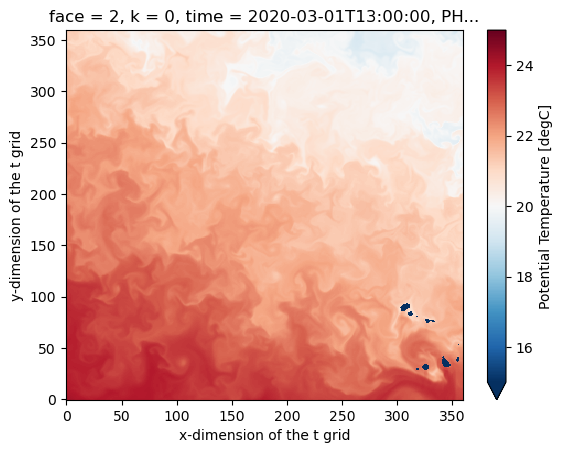

In [5]:
%%time
ds['Theta'].isel(time=1000, k=0, face=2, i=slice(0, 360), j=slice(0, 360)).plot(cmap='RdBu_r', vmin=15, vmax=25);

CPU times: user 1.49 s, sys: 122 ms, total: 1.61 s
Wall time: 1.4 s


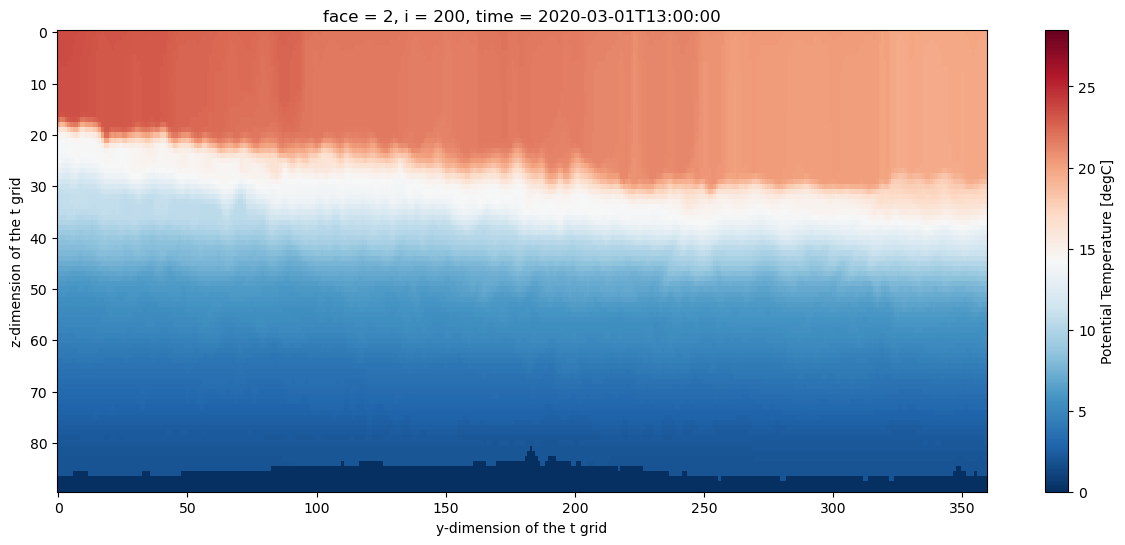

In [6]:
%%time
fig= plt.figure(figsize=(15, 6), frameon=True, facecolor='w')
ds['Theta'].isel(time=1000, face=2, i=200, j=slice(0, 360)).plot(cmap='RdBu_r', yincrease=False, vmin=0, vmax=28.5);

CPU times: user 1.5 s, sys: 101 ms, total: 1.6 s
Wall time: 1.4 s


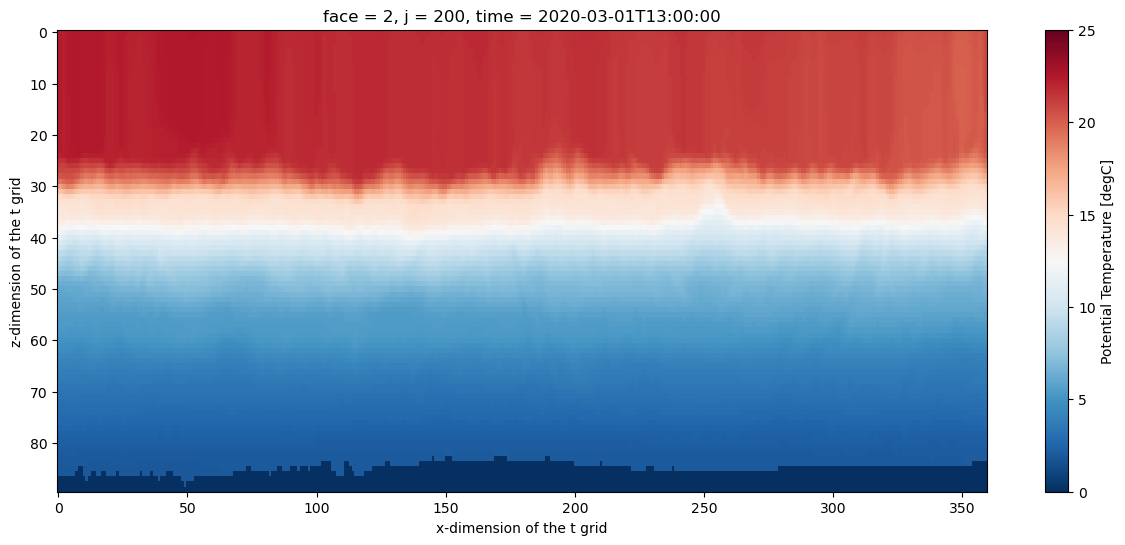

In [7]:
%%time
fig= plt.figure(figsize=(15, 6), frameon=True, facecolor='w')
ds['Theta'].isel(time=1000, face=2, i=slice(0, 360), j=200).plot(cmap='RdBu_r', yincrease=False, vmin=0, vmax=25);

CPU times: user 1.08 s, sys: 41.7 ms, total: 1.12 s
Wall time: 1.1 s


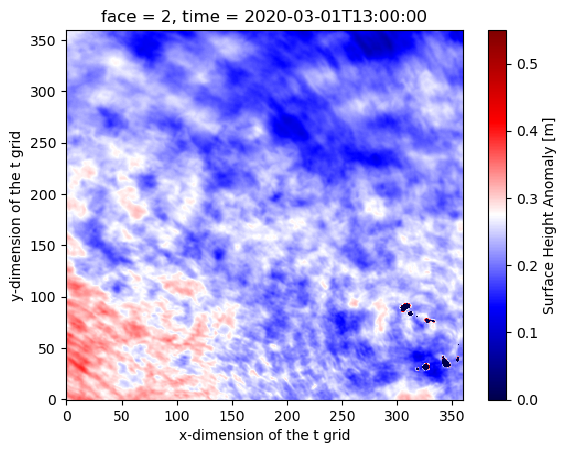

In [8]:
%%time
ds['Eta'].isel(time=1000,face=2, i=slice(0, 360), j=slice(0, 360)).plot(cmap='seismic');